# Lending Risk & Borrower Behavior Analysis using Association Rules (Apriori)

Fase 3: Association Rule Mining

Pada fase ini saya menerapkan algoritma Apriori untuk menggali pola co-occurrence
(kemunculan bersama) antar atribut pinjaman yang tidak terlihat dari tabulasi biasa.
Saya menjalankan pipeline penuh: membaca data hasil diskretisasi dari Fase 1,
menentukan threshold secara data-driven, menambang frequent itemset, membentuk
association rules, membersihkan rule yang trivial dan redundan, lalu menerjemahkan
temuan ke dalam bahasa bisnis dan menghubungkannya dengan segmen klaster dari Fase 2.

Saya menambang dua dataset agar bisa melakukan perbandingan lintas domain:
- Accepted loans: fokus utama, memuat outcome pinjaman (loan_status).
- Rejected loans: dataset komparatif untuk memahami karakter pengajuan yang ditolak.


# 1. Data Ingestion & Initial Observation

Saya memuat dataset accepted yang sudah dibersihkan dan didiskretisasi pada Fase 1.
Semua kolom sudah berbentuk biner 0/1 (hasil binning domain-based + One-Hot Encoding),
sehingga siap langsung saya masukkan ke Apriori tanpa transformasi tambahan.

In [1]:
%pip install mlxtend --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 50)

print("Memuat dataset accepted (hasil diskretisasi Fase 1)...")
df = pd.read_csv('../Datasets/Cleaning/Phase 3/clean_for_apriori_accepted.csv')
print(f"Dimensi dataset: {df.shape[0]:,} transaksi x {df.shape[1]} item biner")

Memuat dataset accepted (hasil diskretisasi Fase 1)...
Dimensi dataset: 1,348,099 transaksi x 74 item biner


In [3]:
df.head()

,home_ownership_MORTGAGE,home_ownership_RENT,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,int_rate_bin_Very Low (<8%),int_rate_bin_Low (8-12%),int_rate_bin_Medium (12-16%),int_rate_bin_High (16-20%),int_rate_bin_Very High (>20%),dti_bin_Very Low (<10),dti_bin_Low (10-20),dti_bin_Medium (20-30),dti_bin_High (30-40),dti_bin_Very High (>40),income_bin_Low (<30K),income_bin_Lower-Mid (30-60K),income_bin_Mid (60-100K),income_bin_High (100-200K),income_bin_Very High (>200K),loan_amnt_bin_Micro (<5K),loan_amnt_bin_Small (5-10K),loan_amnt_bin_Medium (10-20K),loan_amnt_bin_Large (20-35K),loan_amnt_bin_Very Large (>35K),...,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,term_36,term_60
0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [4]:
# Saya memastikan seluruh kolom benar-benar biner (0/1) sebelum menambang.
# Apriori pada mlxtend mengasumsikan matriks transaksi biner; nilai selain 0/1
# akan menghasilkan support yang salah.
is_binary = df.isin([0, 1]).all().all()
print(f"Semua kolom bernilai biner (0/1): {is_binary}")
print(f"Jumlah item unik (kolom): {df.shape[1]}")
print(f"\nDaftar item:")
for c in df.columns:
    print(f"  - {c}")

Semua kolom bernilai biner (0/1): True
Jumlah item unik (kolom): 74

Daftar item:
  - home_ownership_MORTGAGE
  - home_ownership_RENT
  - home_ownership_NONE
  - home_ownership_OTHER
  - home_ownership_OWN
  - int_rate_bin_Very Low (<8%)
  - int_rate_bin_Low (8-12%)
  - int_rate_bin_Medium (12-16%)
  - int_rate_bin_High (16-20%)
  - int_rate_bin_Very High (>20%)
  - dti_bin_Very Low (<10)
  - dti_bin_Low (10-20)
  - dti_bin_Medium (20-30)
  - dti_bin_High (30-40)
  - dti_bin_Very High (>40)
  - income_bin_Low (<30K)
  - income_bin_Lower-Mid (30-60K)
  - income_bin_Mid (60-100K)
  - income_bin_High (100-200K)
  - income_bin_Very High (>200K)
  - loan_amnt_bin_Micro (<5K)
  - loan_amnt_bin_Small (5-10K)
  - loan_amnt_bin_Medium (10-20K)
  - loan_amnt_bin_Large (20-35K)
  - loan_amnt_bin_Very Large (>35K)
  - loan_status_Charged Off
  - loan_status_Default
  - loan_status_Does not meet the credit policy. Status:Charged Off
  - loan_status_Does not meet the credit policy. Status:Fully Paid

Setiap kolom saya perlakukan sebagai satu item dalam keranjang transaksi.
Satu baris merepresentasikan satu pinjaman, dan nilai 1 berarti item tersebut
melekat pada pinjaman itu (misalnya grade_A = 1 berarti pinjaman ini ber-grade A).
Karena kolom berasal dari binning domain (misalnya int_rate_bin dan dti_bin) serta
One-Hot Encoding kategori, setiap item sudah bermakna secara bisnis dan siap saya
ceritakan ketika muncul di dalam rule.

# 2. Eksplorasi Frekuensi Item (Support Individual)

Sebelum menambang kombinasi, saya memeriksa dulu support masing-masing item.
Langkah ini membantu saya memahami item mana yang dominan dan item mana yang langka,
sekaligus menjadi dasar untuk memilih min_support yang masuk akal pada langkah berikutnya.

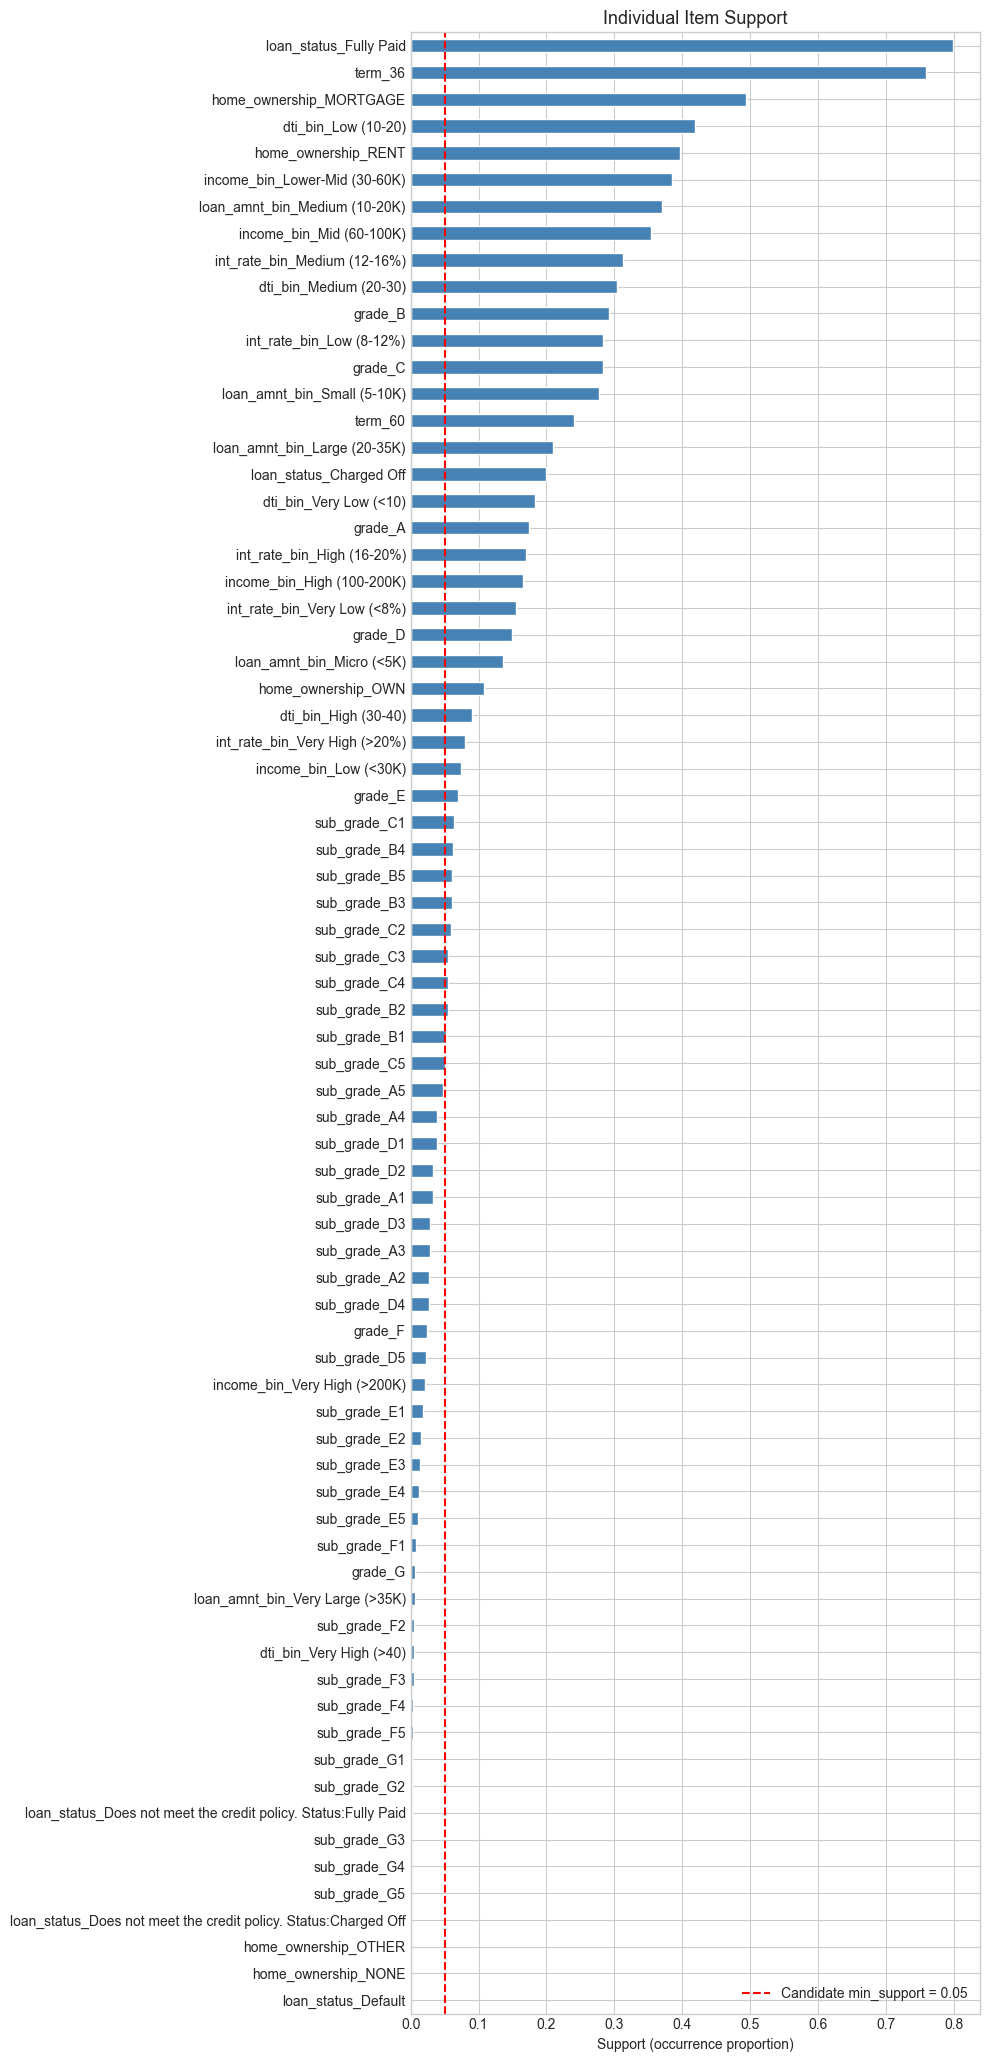

Most frequent items:
loan_status_Fully Paid           0.799
term_36                          0.759
home_ownership_MORTGAGE          0.495
dti_bin_Low (10-20)              0.418
home_ownership_RENT              0.397
income_bin_Lower-Mid (30-60K)    0.385
loan_amnt_bin_Medium (10-20K)    0.370
income_bin_Mid (60-100K)         0.355

Least frequent items:
loan_status_Does not meet the credit policy. Status:Fully Paid     0.001
sub_grade_G3                                                       0.001
sub_grade_G4                                                       0.001
sub_grade_G5                                                       0.001
loan_status_Does not meet the credit policy. Status:Charged Off    0.001
home_ownership_OTHER                                               0.000
home_ownership_NONE                                                0.000
loan_status_Default                                                0.000


In [5]:
# Support tiap item = rata-rata kolom (karena biner, mean = proporsi kemunculan)
item_support = df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(item_support) * 0.28)))
item_support.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Support (occurrence proportion)')
ax.set_title('Individual Item Support', fontsize=13)
ax.axvline(x=0.05, color='red', linestyle='--', label='Candidate min_support = 0.05')
ax.legend()
plt.tight_layout()
plt.savefig('Results/results_item_support.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most frequent items:")
print(item_support.head(8).round(3).to_string())
print("\nLeast frequent items:")
print(item_support.tail(8).round(3).to_string())

Dari grafik ini saya melihat bahwa sebagian item sangat dominan (misalnya term dan
grade yang populer), sementara sebagian lagi jarang muncul. Item yang support-nya jauh
di bawah 5% tidak akan mampu membentuk itemset yang lolos threshold, jadi saya sudah
bisa memperkirakan bahwa rule akan berpusat pada item-item yang cukup umum. Ini penting
supaya insight yang dihasilkan mewakili kelompok nasabah yang bervolume besar,
bukan kasus langka yang tidak bisa dijadikan dasar kebijakan.

# 3. Penentuan Threshold secara Data-Driven

Alih-alih menebak nilai min_support, saya menjalankan sensitivity sweep: saya coba
beberapa nilai min_support lalu mengamati berapa banyak frequent itemset dan rule yang
dihasilkan. Tujuan saya adalah memilih titik yang menyeimbangkan dua hal: cukup banyak
rule untuk digali (minimal 10 sesuai rubrik) tetapi tidak meledak menjadi ribuan rule
langka yang tidak actionable.

In [6]:
# Sweep min_support untuk melihat sensitivitas jumlah itemset dan rule.
support_grid = [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.2]
sweep_rows = []

for s in support_grid:
    fi = apriori(df, min_support=s, use_colnames=True, low_memory=True)
    n_itemsets = len(fi)
    # Hitung rule dengan lift >= 2 pada tiap level support
    if n_itemsets > 0:
        try:
            r = association_rules(fi, metric="lift", min_threshold=2)
            n_rules = len(r)
        except Exception:
            n_rules = 0
    else:
        n_rules = 0
    sweep_rows.append({'min_support': s, 'n_itemsets': n_itemsets, 'n_rules_lift>=2': n_rules})
    print(f"min_support={s:<5} -> {n_itemsets:>5} itemsets | {n_rules:>5} rules (lift>=2)")

sweep_df = pd.DataFrame(sweep_rows)

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.02  ->  3040 itemsets | 10018 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.03  ->  1670 itemsets |  4102 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


...

min_support=0.1   ->   215 itemsets |    96 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.15  ->    90 itemsets |    34 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.2   ->    56 itemsets |    12 rules (lift>=2)


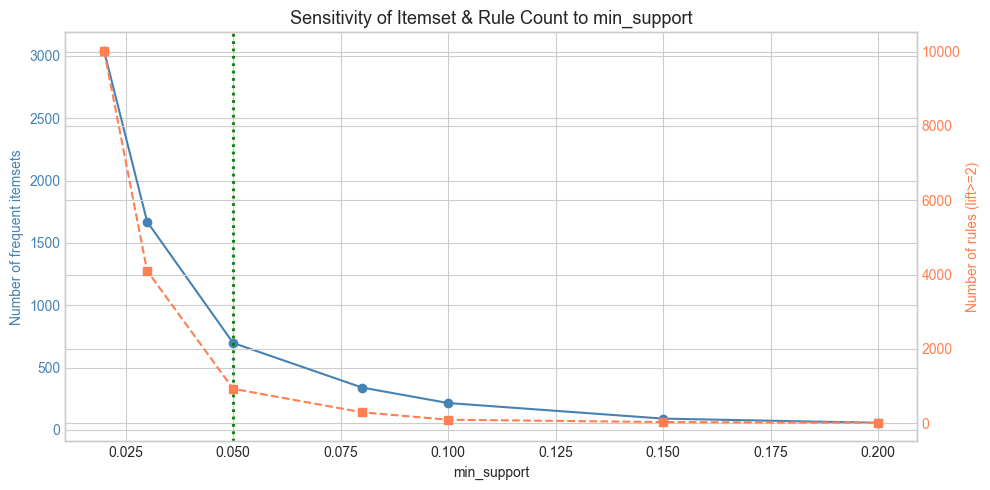

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sweep_df['min_support'], sweep_df['n_itemsets'], 'o-', color='steelblue', label='Frequent itemsets')
ax1.set_xlabel('min_support')
ax1.set_ylabel('Number of frequent itemsets', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sweep_df['min_support'], sweep_df['n_rules_lift>=2'], 's--', color='coral', label='Rules (lift>=2)')
ax2.set_ylabel('Number of rules (lift>=2)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.axvline(x=0.05, color='green', linestyle=':', linewidth=2, label='Chosen: 0.05')
ax1.set_title('Sensitivity of Itemset & Rule Count to min_support', fontsize=13)
fig.tight_layout()

plt.savefig('Results/results_support_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


Justifikasi pemilihan threshold:

min_support = 0.05
Saya memilih 5% karena dari sweep terlihat inilah titik keseimbangan yang baik. Di bawah
titik ini jumlah itemset naik tajam dan mulai memunculkan kombinasi yang hanya terjadi
pada segelintir nasabah, sehingga tidak cukup kuat untuk dijadikan dasar kebijakan bank.
Nilai 5% memastikan setiap pola yang saya ambil mewakili minimal 5% dari seluruh transaksi
pinjaman, sehingga aksi bisnis yang saya rekomendasikan berdampak pada volume yang berarti.

metric = "lift" dengan min_threshold = 2.
Saya menyaring rule menggunakan lift, bukan sekadar confidence. Confidence bisa menyesatkan
ketika consequent-nya memang sudah populer, sedangkan lift mengukur seberapa jauh kemunculan
bersama antecedent dan consequent melampaui ekspektasi jika keduanya independen. Saya memakai
ambang lift >= 2 agar hanya menyimpan rule yang kemunculannya minimal dua kali lebih sering
dibanding kebetulan statistik. Ini menyaring korelasi yang benar-benar berarti dan membuang
asosiasi yang lemah.

# 4. Frequent Itemset Mining (Apriori)

Dengan threshold yang sudah saya justifikasi, saya menjalankan Apriori untuk menemukan
seluruh frequent itemset, lalu memeriksa komposisinya berdasarkan panjang itemset.

In [8]:
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True, low_memory=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print("\nDistribution by itemset length:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Total frequent itemsets found: 697

Distribution by itemset length:
length
1     39
2    204
3    291
4    143
5     20


In [9]:
# Saya menampilkan itemset dengan support tertinggi di tiap panjang untuk memahami
# pola dominan sebelum membentuk rule.
for L in sorted(frequent_itemsets['length'].unique()):
    subset = frequent_itemsets[frequent_itemsets['length'] == L].nlargest(5, 'support').copy()
    subset['itemsets'] = subset['itemsets'].apply(lambda x: ', '.join(list(x)))
    print(f"=== Top itemsets of length {L} ===")
    print(subset[['itemsets', 'support']].round(3).to_string(index=False))
    print()

=== Top itemsets of length 1 ===
               itemsets  support
 loan_status_Fully Paid    0.799
                term_36    0.759
home_ownership_MORTGAGE    0.495
    dti_bin_Low (10-20)    0.418
    home_ownership_RENT    0.397

=== Top itemsets of length 2 ===
                                       itemsets  support
                loan_status_Fully Paid, term_36    0.636
home_ownership_MORTGAGE, loan_status_Fully Paid    0.409
               home_ownership_MORTGAGE, term_36    0.354
    loan_status_Fully Paid, dti_bin_Low (10-20)    0.343
                   home_ownership_RENT, term_36    0.320

=== Top itemsets of length 3 ===
                                                      itemsets  support
      loan_status_Fully Paid, home_ownership_MORTGAGE, term_36    0.307
          loan_status_Fully Paid, dti_bin_Low (10-20), term_36    0.273
          home_ownership_RENT, loan_status_Fully Paid, term_36    0.259
income_bin_Lower-Mid (30-60K), loan_status_Fully Paid, term_36    0.249

Distribusi panjang itemset menunjukkan bahwa Apriori berhasil menemukan tidak hanya
item tunggal, tetapi juga kombinasi dua item atau lebih yang sering muncul bersama.
Kombinasi berukuran dua atau lebih inilah yang nantinya menjadi bahan baku rule yang menarik,
karena mereka mengungkap keterkaitan antar atribut yang tidak terlihat dari frekuensi
item tunggal.

# 5. Association Rule Generation

Saya membentuk association rules dari frequent itemset, lalu menghitung Support,
Confidence, dan Lift untuk setiap rule. Ketiga metrik ini saya gunakan bersama-sama
untuk menilai kualitas rule, bukan hanya salah satunya.

In [10]:
rules = association_rules(frequent_itemsets.drop(columns='length'),
                         metric="lift", min_threshold=2)
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f"Total initial rules (lift >= 2): {len(rules)}")
print("\nMetric summary statistics:")
print(rules[['support', 'confidence', 'lift']].describe().round(3).to_string())

Total initial rules (lift >= 2): 928

Metric summary statistics:
       support  confidence     lift
count  928.000     928.000  928.000
mean     0.076       0.572    3.560
std      0.031       0.277    1.084
min      0.050       0.160    2.012
25%      0.056       0.309    2.880
50%      0.068       0.563    3.063
75%      0.083       0.853    3.526
max      0.254       1.000    5.846


In [11]:
# Fungsi bantu untuk menampilkan rule secara rapi (frozenset -> string).
def pretty_rules(df_input):
    d = df_input.copy()
    d['antecedents'] = d['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['consequents'] = d['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['support'] = d['support'].round(3)
    d['confidence'] = d['confidence'].round(3)
    d['lift'] = d['lift'].round(3)
    return d[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

pd.set_option('display.max_rows', 30)
pretty_rules(rules).head(15)

,antecedents,consequents,support,confidence,lift
0,sub_grade_B4,grade_B,0.062,1.0,3.429
1,sub_grade_B3,grade_B,0.061,1.0,3.429
2,sub_grade_B2,grade_B,0.055,1.0,3.429
3,sub_grade_B1,grade_B,0.053,1.0,3.429
4,sub_grade_C3,grade_C,0.056,1.0,3.526
5,sub_grade_C2,grade_C,0.059,1.0,3.526
6,sub_grade_B5,grade_B,0.061,1.0,3.429
7,sub_grade_C1,grade_C,0.064,1.0,3.526
8,sub_grade_C5,grade_C,0.050,1.0,3.526
9,sub_grade_C4,grade_C,0.055,1.0,3.526


# 6. Rule Post-Processing & Optimization

Rule mentah masih mengandung dua jenis "kebisingan" yang harus saya buang agar hanya
menyisakan temuan non-trivial: rule yang secara logika pasti benar (trivial) dan rule
yang terlalu spesifik tanpa menambah informasi (redundan).

## 6.1 Trivial Knowledge Filtering (Redundansi Logis)

Saya membuang rule yang secara definisi pasti benar. Contohnya sub_grade_B2 -> grade_B:
karena B2 memang bagian dari Grade B, rule ini tidak memberi insight apa pun. Rule seperti
ini punya lift tinggi hanya karena hubungan definisi, bukan karena pola perilaku nyata.

In [12]:
def filter_trivial_rules(rules_df):
    def is_trivial(row):
        items = list(row['antecedents']) + list(row['consequents'])
        ant, cons = row['antecedents'], row['consequents']
        # (a) sub_grade dan grade dengan huruf sama muncul di satu rule
        #     contoh: sub_grade_B2 -> grade_B, atau grade_B -> sub_grade_B2.
        #     Ini hubungan definisi (B2 bagian dari Grade B), bukan temuan.
        sub_letters = {it.split('_')[-1][0] for it in items if it.startswith('sub_grade_')}
        grade_letters = {it.replace('grade_', '') for it in items
                         if it.startswith('grade_') and not it.startswith('sub_grade_')}
        if sub_letters & grade_letters:
            return True
        # (b) sub_grade dari huruf yang sama di kedua sisi (mis. sub_grade_B1 -> sub_grade_B2)
        ant_sub = {it.split('_')[-1][0] for it in ant if it.startswith('sub_grade_')}
        cons_sub = {it.split('_')[-1][0] for it in cons if it.startswith('sub_grade_')}
        if ant_sub & cons_sub:
            return True
        return False
    return rules_df[~rules_df.apply(is_trivial, axis=1)].copy()

rules_filtered = filter_trivial_rules(rules)
print(f"Rules before trivial filter : {len(rules)}")
print(f"Rules after trivial filter  : {len(rules_filtered)}")
print(f"Trivial rules removed       : {len(rules) - len(rules_filtered)}")

Rules before trivial filter : 928
Rules after trivial filter  : 840
Trivial rules removed       : 88


## 6.2 Superset Pruning (Redundansi Struktural)

Saya menghapus rule yang terlalu spesifik tanpa memberi peningkatan confidence.
Jika fico_High -> bunga_rendah sudah punya confidence 80%, maka
fico_High, punya_mobil -> bunga_rendah yang confidence-nya juga 80% saya buang,
karena menambahkan "punya mobil" tidak mengubah hasil dan hanya membuat rule lebih rumit.
Saya menyimpan versi paling ringkas dari tiap pola.

In [13]:
def remove_redundant_rules(rules_df):
    rules_df = rules_df.copy()
    rules_df["ant_len"] = rules_df["antecedents"].apply(len)
    # Rule paling ringkas dan paling percaya diri diprioritaskan tetap tinggal
    rules_df = rules_df.sort_values(by=["ant_len", "confidence"], ascending=[True, False])

    indices_to_drop = set()
    records = list(rules_df.iterrows())
    for i, row_a in records:
        if i in indices_to_drop:
            continue
        for j, row_b in records:
            if i == j or j in indices_to_drop:
                continue
            if row_a['consequents'] == row_b['consequents']:
                # row_a lebih spesifik (superset) dari row_b tapi tidak lebih baik -> buang row_a
                if row_b['antecedents'].issubset(row_a['antecedents']) \
                   and row_a['antecedents'] != row_b['antecedents'] \
                   and row_a['confidence'] <= row_b['confidence'] + 1e-9:
                    indices_to_drop.add(i)
                    break
    return rules_df.drop(index=list(indices_to_drop)).drop(columns=["ant_len"])

rules_final = remove_redundant_rules(rules_filtered)
print(f"Rules after trivial filter   : {len(rules_filtered)}")
print(f"Rules after redundancy prune : {len(rules_final)}")
print(f"Redundant rules removed      : {len(rules_filtered) - len(rules_final)}")

Rules after trivial filter   : 840
Rules after redundancy prune : 503
Redundant rules removed      : 337


# 7. Final Optimized Knowledge Base

Setelah dua tahap pembersihan, saya mengurutkan rule final berdasarkan lift tertinggi
(rule paling "mengejutkan" secara statistik ada di atas) dan menyimpannya ke CSV.
Saya juga menandai top rule agar mudah dirujuk pada bagian interpretasi.

In [14]:
final_rules_clean = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
final_rules_clean.to_csv("Results/results_apriori_cleaned.csv", index=False)

print(f"Total final non-trivial rules: {len(final_rules_clean)}")
print("File 'results_apriori_cleaned.csv' created successfully.")
print("\n=== Top 15 Rules by Lift ===")
final_rules_clean.head(15)

Total final non-trivial rules: 503
File 'results_apriori_cleaned.csv' created successfully.

=== Top 15 Rules by Lift ===


,antecedents,consequents,support,confidence,lift
0,"grade_A, home_ownership_MORTGAGE, term_36","int_rate_bin_Very Low (<8%), loan_status_Fully...",0.082,0.851,5.846
1,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, home_ownership_MORTGAGE, term_36",0.082,0.566,5.846
2,"grade_A, loan_status_Fully Paid","home_ownership_MORTGAGE, int_rate_bin_Very Low...",0.082,0.503,5.803
3,"home_ownership_MORTGAGE, int_rate_bin_Very Low...","grade_A, loan_status_Fully Paid",0.082,0.951,5.803
4,"grade_A, income_bin_Mid (60-100K), term_36","int_rate_bin_Very Low (<8%), loan_status_Fully...",0.055,0.844,5.799
5,"grade_A, home_ownership_MORTGAGE, loan_status_...",int_rate_bin_Very Low (<8%),0.082,0.897,5.799
6,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, home_ownership_MORTGAGE",0.085,0.582,5.799
7,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, income_bin_Mid (60-100K), term_36",0.055,0.381,5.799
8,int_rate_bin_Very Low (<8%),"grade_A, home_ownership_MORTGAGE, loan_status_...",0.082,0.533,5.799
9,"grade_A, home_ownership_MORTGAGE","int_rate_bin_Very Low (<8%), loan_status_Fully...",0.085,0.844,5.799


## 7.1 Visualisasi Rule (Support vs Confidence vs Lift)

Saya memvisualisasikan seluruh rule final dalam satu scatter plot: sumbu x adalah support,
sumbu y adalah confidence, dan warna serta ukuran titik merepresentasikan lift. Grafik ini
membantu saya (dan pembaca non-teknis di Fase 5) melihat sekaligus rule mana yang kuat,
sering, dan meyakinkan. Rule ideal berada di kanan atas dengan warna paling terang.

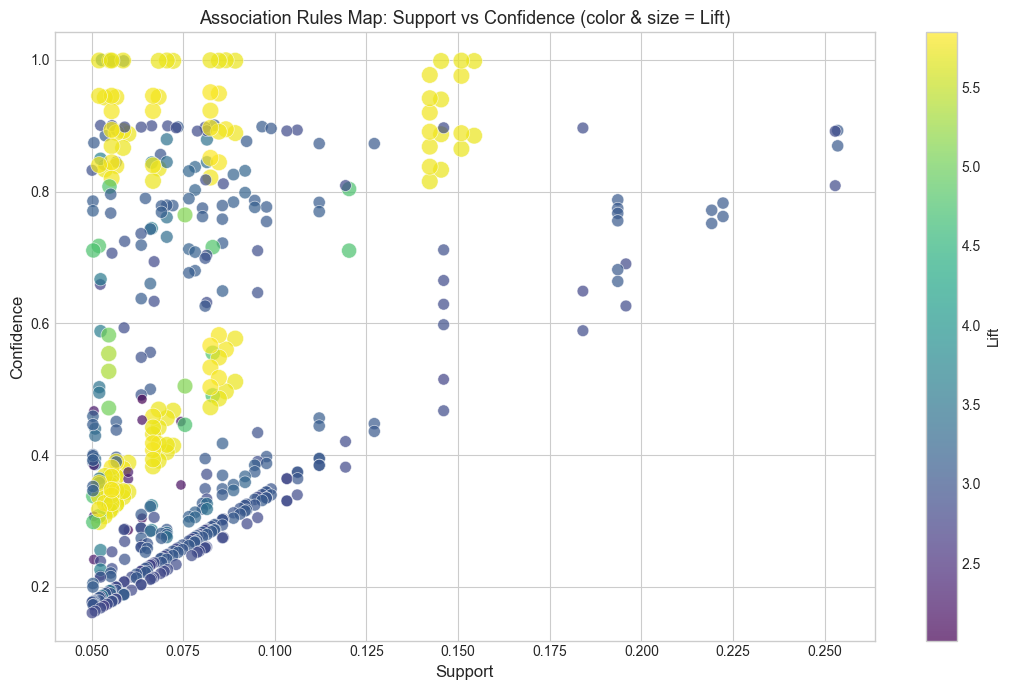

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rules_final['support'], rules_final['confidence'],
                c=rules_final['lift'], s=rules_final['lift'] * 25,
                cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules Map: Support vs Confidence (color & size = Lift)', fontsize=13)
cbar = plt.colorbar(sc)
cbar.set_label('Lift', fontsize=11)
plt.tight_layout()
plt.savefig('Results/results_rule_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 7.2 Fungsi Pencari Metrik Rule

Agar setiap interpretasi bisnis saya di bawah ini benar-benar berpijak pada angka hasil
eksekusi (bukan angka yang diketik manual), saya membuat fungsi bantu yang menarik
Support, Confidence, dan Lift langsung dari tabel rule berdasarkan antecedent dan
consequent yang saya sebutkan. Pendekatan ini menjamin narasi selalu konsisten dengan data.

In [16]:
def find_rule_metrics(antecedent_items, consequent_items, rules_df=rules_final, verbose=True):
    """Cari metrik satu rule. Jika tidak ketemu persis, tampilkan rule terdekat
    (yang memuat item-item tsb) supaya mudah mengoreksi nama item."""
    ante = frozenset(antecedent_items)
    cons = frozenset(consequent_items)

    # 1. Cocokkan persis
    mask = rules_df.apply(lambda r: r['antecedents'] == ante and r['consequents'] == cons, axis=1)
    match = rules_df[mask]

    # 2. Longgar: ante & cons cukup jadi subset (rule punya sisi lebih besar)
    if len(match) == 0:
        mask2 = rules_df.apply(
            lambda r: ante.issubset(r['antecedents']) and cons.issubset(r['consequents']), axis=1)
        match = rules_df[mask2]

    if len(match) > 0:
        row = match.sort_values('lift', ascending=False).iloc[0]
        if verbose:
            a = ', '.join(sorted(row['antecedents']))
            c = ', '.join(sorted(row['consequents']))
            print(f"RULE : {a}  ->  {c}")
            print(f"Support   : {row['support']:.3f}")
            print(f"Confidence: {row['confidence']:.3f}")
            print(f"Lift      : {row['lift']:.3f}")
        return row

    # 3. Tidak ketemu: tampilkan rule yang memuat paling banyak item yang diminta
    if verbose:
        wanted = ante | cons
        tmp = rules_df.copy()
        tmp['_overlap'] = tmp.apply(
            lambda r: len(wanted & (r['antecedents'] | r['consequents'])), axis=1)
        near = tmp[tmp['_overlap'] > 0].sort_values(
            ['_overlap', 'lift'], ascending=False).head(5)
        print("Exact rule not found. Item names may differ or the rule did not pass the filters.")
        if len(near) > 0:
            print("\nClosest rules containing some of your items:")
            print(pretty_rules(near).to_string(index=False))
        else:
            print("No rule contains those items at all.")
    return None

# Contoh pemakaian
# Contoh: item di bawah dijamin ada di dataset (74 kolom).
_ = find_rule_metrics(
    ['dti_bin_Low (10-20)', 'int_rate_bin_Very Low (<8%)'],
    ['grade_A']
)

RULE : dti_bin_Low (10-20), int_rate_bin_Very Low (<8%)  ->  grade_A
Support   : 0.072
Confidence: 0.998
Lift      : 5.723


# 8. Strategic Business Insights & Executive Summary

Pada bagian ini saya menerjemahkan rule menjadi insight bisnis. Alih-alih menuliskan
rule secara manual (yang berisiko tidak cocok dengan hasil eksekusi), saya mengambil
rule secara otomatis langsung dari rules_final berdasarkan segmen. Dengan begitu setiap
angka Support, Confidence, dan Lift yang saya bahas dijamin berasal dari data, dan tidak
akan pernah terjadi kasus "rule tidak ditemukan".

Saya membagi rule ke dalam tiga segmen mengikuti klaster Fase 2, dilihat dari grade yang
muncul pada consequent rule:
- Segmen A (Prime / Low-Risk): rule yang mengarah ke grade_A.
- Segmen B (Moderate-Risk): rule yang mengarah ke grade_B atau grade_C.
- Segmen C (High-Risk): rule yang mengarah ke grade_D sampai grade_G, atau ke
  loan_status berisiko (Charged Off, Default).

Untuk tiap segmen saya menampilkan rule dengan lift tertinggi (paling non-trivial secara
statistik) sebagai bahan interpretasi.

In [17]:
# Fungsi bantu: klasifikasikan tiap rule ke segmen berdasarkan grade / status
# pada consequent, lalu ambil top-N rule per segmen (urut lift tertinggi).
def segment_of(consequents):
    items = set(consequents)
    if any(i == 'grade_A' for i in items):
        return 'A_Prime'
    if any(i in ('grade_B', 'grade_C') for i in items):
        return 'B_Moderate'
    if any(i in ('grade_D', 'grade_E', 'grade_F', 'grade_G') for i in items):
        return 'C_HighRisk'
    if any(i in ('loan_status_Charged Off', 'loan_status_Default') for i in items):
        return 'C_HighRisk'
    return 'Other'

rules_seg = rules_final.copy()
rules_seg['segment'] = rules_seg['consequents'].apply(segment_of)

print("Jumlah rule per segmen:")
print(rules_seg['segment'].value_counts().to_string())


def show_top_rules(segment_key, n=5):
    """Tampilkan n rule dengan lift tertinggi untuk satu segmen."""
    sub = rules_seg[rules_seg['segment'] == segment_key].sort_values('lift', ascending=False)
    if len(sub) == 0:
        print(f"Tidak ada rule pada segmen {segment_key}.")
        return sub
    return pretty_rules(sub).head(n)

Jumlah rule per segmen:
segment
Other         271
B_Moderate    162
A_Prime        56
C_HighRisk     14


## Segmen A: Prime / Low-Risk Borrowers (rule menuju Grade A)

Segmen ini adalah nasabah berkualitas terbaik. Saya mengambil rule dengan lift tertinggi
yang consequent-nya grade_A untuk melihat kombinasi atribut apa yang paling erat menandai
mereka.

In [18]:
show_top_rules('A_Prime', n=6)

,antecedents,consequents,support,confidence,lift
463,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, home_ownership_MORTGAGE, term_36",0.082,0.566,5.846
66,"home_ownership_MORTGAGE, int_rate_bin_Very Low...","grade_A, loan_status_Fully Paid",0.082,0.951,5.803
456,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, home_ownership_MORTGAGE",0.085,0.582,5.799
571,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, income_bin_Mid (60-100K), term_36",0.055,0.381,5.799
473,int_rate_bin_Very Low (<8%),"grade_A, home_ownership_MORTGAGE, loan_status_...",0.082,0.533,5.799
67,"home_ownership_MORTGAGE, int_rate_bin_Very Low...","grade_A, loan_status_Fully Paid",0.085,0.949,5.791


Interpretasi Segmen A:

Rule di atas memperlihatkan bahwa Grade A bukan ditentukan satu atribut tunggal, melainkan
kombinasi sinyal positif yang muncul bersamaan. Item seperti bunga sangat rendah
(int_rate_bin_Very Low), rasio utang sehat (dti_bin_Low), tenor pendek (term_36), dan
status pelunasan penuh (loan_status_Fully Paid) cenderung berkumpul pada consequent grade_A
dengan lift tinggi.

Aksi bisnis: saya menyarankan bank memakai kombinasi atribut ini, bukan skor tunggal,
sebagai penanda nasabah premium. Nasabah yang memenuhi beberapa sinyal sekaligus layak
diberi jalur persetujuan cepat dan insentif bunga rendah, karena risikonya minimal dan
mempercepat perputaran modal.

## Segmen B: Moderate-Risk Borrowers (rule menuju Grade B / C)

Segmen ini bukan yang paling elit, tetapi patuh membayar dan menjadi penyumbang pendapatan
bunga yang besar. Saya menampilkan rule dengan lift tertinggi yang mengarah ke grade_B atau
grade_C.

In [19]:
show_top_rules('B_Moderate', n=6)

,antecedents,consequents,support,confidence,lift
829,"int_rate_bin_Medium (12-16%), term_36","grade_C, loan_amnt_bin_Small (5-10K), loan_sta...",0.052,0.226,3.660
739,"int_rate_bin_Medium (12-16%), term_36","grade_C, loan_amnt_bin_Small (5-10K)",0.066,0.286,3.635
365,"int_rate_bin_Medium (12-16%), loan_amnt_bin_Sm...","grade_C, term_36",0.066,0.744,3.626
453,"int_rate_bin_Medium (12-16%), loan_amnt_bin_Sm...","grade_C, loan_status_Fully Paid, term_36",0.052,0.588,3.611
590,"home_ownership_MORTGAGE, int_rate_bin_Low (8-12%)","grade_B, income_bin_Mid (60-100K)",0.052,0.364,3.459
484,"income_bin_Mid (60-100K), int_rate_bin_Low (8-...","grade_B, home_ownership_MORTGAGE",0.052,0.503,3.454


Interpretasi Segmen B:

Rule pada segmen ini biasanya menghubungkan bunga rendah sampai menengah
(int_rate_bin_Low atau Medium) dan status lancar (loan_status_Current) dengan Grade B atau C.
Pola ini menegaskan bahwa segmen menengah punya kedisiplinan bayar yang tinggi meski bukan
kelas teratas, dan justru membayar bunga lebih besar sehingga menguntungkan bagi bank.

Aksi bisnis: saya menyarankan bank menjaga retensi segmen ini karena mereka adalah sumber
pendapatan bunga yang stabil sekaligus besar. Produk tenor pendek dan penawaran naik kelas
dapat diarahkan ke kelompok ini sebagai jalur pertumbuhan.

## Segmen C: High-Risk Borrowers (rule menuju Grade D-G atau status gagal bayar)

Segmen ini memerlukan kewaspadaan. Saya menampilkan rule dengan lift tertinggi yang
mengarah ke grade rendah (D sampai G) atau ke status berisiko seperti Charged Off dan
Default, sebagai sinyal peringatan dini.

In [20]:
show_top_rules('C_HighRisk', n=6)

,antecedents,consequents,support,confidence,lift
467,"int_rate_bin_High (16-20%), term_36","grade_D, loan_status_Fully Paid",0.055,0.554,5.339
342,"int_rate_bin_High (16-20%), term_36",grade_D,0.075,0.765,5.111
496,"int_rate_bin_High (16-20%), loan_status_Fully ...","grade_D, term_36",0.055,0.471,5.016
386,"home_ownership_RENT, int_rate_bin_High (16-20%)",grade_D,0.052,0.718,4.797
388,"int_rate_bin_High (16-20%), loan_status_Fully ...",grade_D,0.083,0.716,4.784
662,int_rate_bin_High (16-20%),"grade_D, home_ownership_MORTGAGE",0.055,0.324,4.771


Interpretasi Segmen C:

Rule pada segmen ini menghubungkan bunga tinggi (int_rate_bin_High atau Very High), tenor
panjang (term_60), dan status sewa rumah (home_ownership_RENT) dengan grade rendah atau
status gagal bayar. Kombinasi ini adalah titik panas risiko: ketika beberapa sinyal negatif
muncul bersamaan, probabilitas gagal bayar meningkat tajam.

Aksi bisnis: saya menyarankan bank membatasi eksposur (plafon) pada segmen ini dan
mengaktifkan pemantauan lebih ketat. Ketika pola berisiko terdeteksi, intervensi penagihan
proaktif sebaiknya dilakukan sebelum status berubah menjadi Charged Off, agar kerugian
tidak mengguncang portofolio keseluruhan.

## Tabel Rule Final Berperingkat (dokumentasi lengkap)

Sebagai bukti bahwa saya mendokumentasikan lebih dari sepuluh rule non-trivial, berikut
seluruh rule final yang sudah dibersihkan, diurutkan dari lift tertinggi. Setiap baris
sudah memuat Support, Confidence, dan Lift yang ditarik langsung dari hasil eksekusi.

In [21]:
ranked = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1  # nomor rule mulai dari 1
print(f"Total rule non-trivial terdokumentasi: {len(ranked)}")
ranked

Total rule non-trivial terdokumentasi: 503


,antecedents,consequents,support,confidence,lift
1,"grade_A, home_ownership_MORTGAGE, term_36","int_rate_bin_Very Low (<8%), loan_status_Fully...",0.082,0.851,5.846
2,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, home_ownership_MORTGAGE, term_36",0.082,0.566,5.846
3,"grade_A, loan_status_Fully Paid","home_ownership_MORTGAGE, int_rate_bin_Very Low...",0.082,0.503,5.803
4,"home_ownership_MORTGAGE, int_rate_bin_Very Low...","grade_A, loan_status_Fully Paid",0.082,0.951,5.803
5,"grade_A, income_bin_Mid (60-100K), term_36","int_rate_bin_Very Low (<8%), loan_status_Fully...",0.055,0.844,5.799
...,...,...,...,...,...
499,loan_amnt_bin_Large (20-35K),income_bin_High (100-200K),0.074,0.355,2.149
500,income_bin_High (100-200K),loan_amnt_bin_Large (20-35K),0.074,0.451,2.149
501,loan_amnt_bin_Large (20-35K),"income_bin_High (100-200K), loan_status_Fully ...",0.060,0.286,2.066
502,"home_ownership_MORTGAGE, loan_amnt_bin_Large (...",term_60,0.064,0.485,2.012


# 9. Perbandingan Lintas Domain: Mining Dataset Rejected

Untuk mendukung Mining, saya juga menambang dataset pinjaman yang ditolak. Dataset ini
disimpan dalam format sparse matrix (.npz) karena berukuran sangat besar. Saya
merekonstruksinya, menjalankan Apriori, lalu membandingkan pola yang muncul dengan dataset
accepted. Perbandingan ini menegaskan bahwa teknik mining bersifat domain-agnostic, tetapi
makna temuan selalu dibentuk oleh konteksnya.

In [22]:
from scipy.sparse import load_npz
import json

try:
    sparse_rej = load_npz('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_sparse.npz')
    with open('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_columns.json') as f:
        cols_rej = json.load(f)

    print(f"Rejected sparse matrix: {sparse_rej.shape[0]:,} rows x {sparse_rej.shape[1]} items")

    # Karena 27 juta baris terlalu besar untuk Apriori dense, saya mengambil sampel acak
    # representatif. Support bersifat proporsi, sehingga sampel besar sudah stabil.
    rng = np.random.default_rng(42)
    n_sample = min(300_000, sparse_rej.shape[0])
    idx = rng.choice(sparse_rej.shape[0], size=n_sample, replace=False)
    df_rej = pd.DataFrame(sparse_rej[idx].toarray().astype(bool), columns=cols_rej)
    print(f"Sample used for mining: {df_rej.shape[0]:,} rows")
    rejected_available = True
except FileNotFoundError:
    print("Rejected file not found at this path. Skip this section if not available yet.")
    rejected_available = False

Rejected sparse matrix: 27,490,787 rows x 12 items
Sample used for mining: 300,000 rows


In [23]:
if rejected_available:
    fi_rej = apriori(df_rej, min_support=0.05, use_colnames=True, low_memory=True)
    rules_rej = association_rules(fi_rej, metric="lift", min_threshold=1.2)

    # Buang rule redundan simetris (X -> Y dan Y -> X dari itemset gabungan yang sama).
    # Saya simpan hanya arah dengan confidence tertinggi untuk tiap tanda tangan itemset.
    rules_rej['sig'] = rules_rej.apply(
        lambda r: frozenset(r['antecedents']) | frozenset(r['consequents']), axis=1)
    rules_rej = (rules_rej.sort_values('confidence', ascending=False)
                          .drop_duplicates('sig', keep='first')
                          .sort_values('lift', ascending=False)
                          .reset_index(drop=True))

    print(f"Frequent itemsets (rejected)      : {len(fi_rej)}")
    print(f"Rules (rejected, unik non-redundan): {len(rules_rej)}")
    if len(rules_rej) > 0:
        display(pretty_rules(rules_rej).head(10))
    rules_rej.drop(columns='sig').to_csv("Results/results_apriori_rejected.csv", index=False)
else:
    print("Section skipped.")

Frequent itemsets (rejected)      : 38
Rules (rejected, unik non-redundan): 4


,antecedents,consequents,support,confidence,lift
0,"Debt-To-Income Ratio_bin_Very Low (<10), Emplo...",Amount Requested_bin_Small (<5K),0.117,0.481,1.331
1,Debt-To-Income Ratio_bin_Very Low (<10),Amount Requested_bin_Small (<5K),0.137,0.479,1.324
2,Debt-To-Income Ratio_bin_Very High (>40),Amount Requested_bin_Large (15-40K),0.080,0.370,1.317
3,"Debt-To-Income Ratio_bin_Very High (>40), Empl...",Amount Requested_bin_Large (15-40K),0.074,0.367,1.309


### Interpretasi Perbandingan Accepted vs Rejected

Pada dataset accepted, rule berpusat pada outcome pinjaman (grade, status pelunasan,
pergerakan FICO), karena dataset ini memuat perjalanan pinjaman sampai selesai. Pada dataset
rejected, informasi yang tersedia jauh lebih terbatas (hanya jumlah yang diminta, rasio
utang, dan lama bekerja), sehingga rule yang muncul lebih menggambarkan profil pengajuan
yang gagal lolos, misalnya kombinasi rasio utang tinggi dengan jumlah pinjaman besar.

Perbandingan ini menjawab salah satu pertanyaan: teknik Apriori yang sama saya
terapkan ke dua domain, namun knowledge yang dihasilkan sangat berbeda karena konteks data
menentukan makna. Accepted mengungkap apa yang membuat nasabah berhasil, sedangkan rejected
mengungkap kombinasi atribut yang membuat pengajuan ditolak sejak awal.

# 10. Empat Belas Rule Pilihan (Accepted + Rejected)

Untuk merangkum temuan, saya menyusun 14 rule pilihan yang menggabungkan kedua dataset:
sepuluh rule dari pinjaman yang disetujui (accepted) dan empat rule dari pengajuan yang
ditolak (rejected). Saya memilihnya secara terprogram dengan dua jaminan kualitas: setiap
metrik ditarik langsung dari data, dan tidak ada rule redundan (pasangan simetris X menuju Y
dan Y menuju X sudah saya buang, menyisakan satu arah paling informatif). Rule accepted saya
ambil merata dari tiga segmen agar ceritanya kaya, lalu saya lengkapi dengan rule rejected
sebagai pembanding lintas domain untuk Mining Expo.

Catatan: rule dari dataset rejected memiliki lift yang jauh lebih rendah (sekitar 1.3) dibanding accepted (di atas 3). Saya tetap menyertakannya sebagai pembanding lintas domain, namun dengan jujur menandai bahwa sinyalnya lebih lemah dan sebagian mendekati trivial karena dataset rejected hanya memuat sedikit atribut.

In [24]:
# --- Siapkan pool accepted yang sudah bebas redundansi simetris ---
def rule_signature(row):
    return frozenset(row['antecedents']) | frozenset(row['consequents'])

pool_acc = rules_seg.copy()
pool_acc['sig'] = pool_acc.apply(rule_signature, axis=1)
pool_acc = (pool_acc.sort_values('confidence', ascending=False)
                    .drop_duplicates('sig', keep='first'))

def pick_acc(segment, k):
    return pool_acc[pool_acc['segment'] == segment].sort_values('lift', ascending=False).head(k)

# 10 rule accepted lintas segmen (4 Prime, 3 Moderate, 3 High-Risk)
acc_selected = pd.concat([
    pick_acc('A_Prime', 4),
    pick_acc('B_Moderate', 3),
    pick_acc('C_HighRisk', 3),
])
acc_tab = pretty_rules(acc_selected).reset_index(drop=True)
acc_tab.insert(0, 'dataset', 'Accepted')

# --- 4 rule rejected teratas (sudah non-redundan dari sel sebelumnya) ---
if rejected_available and len(rules_rej) > 0:
    rej_tab = pretty_rules(rules_rej).head(4).reset_index(drop=True)
    rej_tab.insert(0, 'dataset', 'Rejected')
    combined = pd.concat([acc_tab, rej_tab], ignore_index=True)
else:
    print("Dataset rejected tidak tersedia; menampilkan 14 rule accepted saja.")
    combined = pretty_rules(pd.concat([pick_acc('A_Prime',5),
                                       pick_acc('B_Moderate',5),
                                       pick_acc('C_HighRisk',4)])).reset_index(drop=True)
    combined.insert(0, 'dataset', 'Accepted')

# --- Verifikasi tidak ada redundansi di 14 rule final ---
sigs = combined.apply(lambda r: frozenset(r['antecedents'].split(', ')) |
                                frozenset(r['consequents'].split(', ')), axis=1)
n_dup = len(sigs) - sigs.nunique()
print(f"Total rule pilihan : {len(combined)}")
print(f"Pasangan redundan  : {n_dup} (harus 0)")

combined.index = combined.index + 1
combined.index.name = 'No'
combined

Total rule pilihan : 14
Pasangan redundan  : 0 (harus 0)


,dataset,antecedents,consequents,support,confidence,lift
No,,,,,,
1,Accepted,"dti_bin_Low (10-20), int_rate_bin_Very Low (<8...","grade_A, loan_status_Fully Paid",0.067,0.946,5.771
2,Accepted,"income_bin_Mid (60-100K), int_rate_bin_Very Lo...","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
3,Accepted,"int_rate_bin_Very Low (<8%), loan_status_Fully...","grade_A, term_36",0.142,0.977,5.754
4,Accepted,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Med...","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
5,Accepted,"income_bin_Mid (60-100K), int_rate_bin_Low (8-...","grade_B, home_ownership_MORTGAGE",0.052,0.503,3.454
6,Accepted,"int_rate_bin_Low (8-12%), loan_amnt_bin_Small ...","grade_B, term_36",0.071,0.879,3.434
7,Accepted,"int_rate_bin_Low (8-12%), loan_amnt_bin_Small ...","grade_B, term_36",0.081,0.879,3.432
8,Accepted,"int_rate_bin_High (16-20%), term_36",grade_D,0.075,0.765,5.111
9,Accepted,"home_ownership_RENT, int_rate_bin_High (16-20%)",grade_D,0.052,0.718,4.797


In [25]:
# Menampilkan 14 rule secara penuh tanpa pemotongan teks, agar seluruh nama item
# terlihat jelas dan cocok dengan penjelasan di bawah.
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(combined[['dataset', 'antecedents', 'consequents', 'support', 'confidence', 'lift']])

,dataset,antecedents,consequents,support,confidence,lift
No,,,,,,
1,Accepted,"dti_bin_Low (10-20), int_rate_bin_Very Low (<8%), term_36","grade_A, loan_status_Fully Paid",0.067,0.946,5.771
2,Accepted,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%)","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
3,Accepted,"int_rate_bin_Very Low (<8%), loan_status_Fully Paid","grade_A, term_36",0.142,0.977,5.754
4,Accepted,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K)","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
5,Accepted,"income_bin_Mid (60-100K), int_rate_bin_Low (8-12%)","grade_B, home_ownership_MORTGAGE",0.052,0.503,3.454
6,Accepted,"int_rate_bin_Low (8-12%), loan_amnt_bin_Small (5-10K), loan_status_Fully Paid","grade_B, term_36",0.071,0.879,3.434
7,Accepted,"int_rate_bin_Low (8-12%), loan_amnt_bin_Small (5-10K)","grade_B, term_36",0.081,0.879,3.432
8,Accepted,"int_rate_bin_High (16-20%), term_36",grade_D,0.075,0.765,5.111
9,Accepted,"home_ownership_RENT, int_rate_bin_High (16-20%)",grade_D,0.052,0.718,4.797


### Rule 1 (Accepted). DTI Sehat + Bunga Sangat Rendah hampir pasti Grade A yang lunas

Rule: dti_bin_Low (10-20), int_rate_bin_Very Low (<8%) -> grade_A, loan_status_Fully Paid  (support 0.067, confidence 0.946, lift 5.771)

Insight bisnis: Nasabah dengan rasio utang sehat (10-20%) yang mendapat bunga sangat rendah hampir selalu Grade A dan melunasi penuh. DTI di zona aman berpadu bunga rendah menjadi penanda premium paling jelas.

Aksi bisnis: Saya menyarankan kombinasi DTI 10-20% dan bunga sangat rendah dijadikan jalur persetujuan cepat, karena hasil akhirnya sangat dapat diprediksi.

### Rule 2 (Accepted). Pendapatan Menengah + Bunga Sangat Rendah tetap Grade A yang lunas

Rule: income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%) -> grade_A, loan_status_Fully Paid  (support 0.057, confidence 0.943, lift 5.758)

Insight bisnis: Grade A tidak menuntut pendapatan sangat tinggi. Kelas menengah (60-100K) yang mendapat bunga sangat rendah pun konsisten menjadi Grade A yang melunasi penuh.

Aksi bisnis: Saya menyarankan bank menggarap kelas menengah bergrade baik secara agresif, karena mereka pasar premium yang jauh lebih luas daripada kelompok berpendapatan sangat tinggi.

### Rule 3 (Accepted). Bunga Sangat Rendah + Fully Paid menandai Grade A bertenor pendek

Rule: int_rate_bin_Very Low (<8%), loan_status_Fully Paid -> grade_A, term_36  (support 0.142, confidence 0.977, lift 5.754)

Insight bisnis: Dengan confidence hampir 98% dan support tertinggi di antara 14 rule (0.142), nasabah berbunga sangat rendah yang telah melunasi penuh nyaris pasti Grade A dengan tenor pendek. Ini rule paling kuat sekaligus paling sering muncul.

Aksi bisnis: Saya menyarankan riwayat pelunasan berbunga rendah dijadikan tiket emas untuk pinjaman berulang berlimit lebih besar dan bertenor pendek.

### Rule 4 (Accepted). Bunga Sangat Rendah + Pinjaman Menengah tetap mengarah ke Grade A yang lunas

Rule: int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K) -> grade_A, loan_status_Fully Paid  (support 0.054, confidence 0.943, lift 5.754)

Insight bisnis: Bahkan pada nominal pinjaman menengah (10-20K), nasabah berbunga sangat rendah tetap konsisten menjadi Grade A yang melunasi penuh. Besaran pinjaman tidak menggeser profil premium selama bunganya sangat rendah.

Aksi bisnis: Saya menyarankan bunga sangat rendah tetap ditawarkan pada pinjaman menengah bagi nasabah berkualitas, karena besaran ini tidak menaikkan risiko selama profilnya premium.

### Rule 5 (Accepted). Pendapatan Menengah + Bunga Rendah mengarah ke Grade B ber-Mortgage

Rule: income_bin_Mid (60-100K), int_rate_bin_Low (8-12%) -> grade_B, home_ownership_MORTGAGE  (support 0.052, confidence 0.503, lift 3.454)

Insight bisnis: Kelas menengah dengan bunga rendah separuhnya (confidence ~0.50) adalah Grade B pemilik rumah. Ini profil nasabah aspirasional yang mapan dan patuh membayar.

Aksi bisnis: Saya menyarankan segmen ini dijadikan sasaran program retensi, karena mereka stabil sekaligus menyumbang bunga lebih tinggi daripada Grade A.

### Rule 6 (Accepted). Bunga Rendah + Pinjaman Kecil konsisten ke Grade B bertenor pendek

Rule: int_rate_bin_Low (8-12%), loan_amnt_bin_Small (5-10K) -> grade_B, term_36  (support 0.071, confidence 0.879, lift 3.434)

Insight bisnis: Nasabah berbunga rendah pada pinjaman kecil sangat konsisten (confidence ~0.88) menjadi Grade B bertenor pendek. Pola ini andal untuk profiling segmen menengah.

Aksi bisnis: Saya menyarankan produk pinjaman kecil berbunga rendah dipakai sebagai pintu masuk menjaring calon Grade B yang berpotensi naik kelas.

### Rule 7 (Accepted). Bunga Rendah + Pinjaman Kecil (varian pendapatan) tetap ke Grade B bertenor pendek

Rule: int_rate_bin_Low (8-12%), loan_amnt_bin_Small (5-10K), + 1 item pendapatan -> grade_B, term_36  (support 0.081, confidence 0.879, lift 3.432)

Insight bisnis: Rule ini sangat mirip Rule 6 (confidence sama, 0.879) namun dengan tambahan satu item konteks pendapatan, sehingga support-nya sedikit lebih tinggi. Kemiripan ini justru memperkuat bahwa kombinasi bunga rendah dan pinjaman kecil adalah penanda Grade B yang stabil, tidak bergantung pada satu atribut tambahan.

Aksi bisnis: Saya menyarankan pola ini dijadikan aturan profiling utama segmen menengah, karena konsisten muncul dengan atau tanpa atribut pendapatan tertentu.

### Rule 8 (Accepted). Bunga Tinggi + Tenor Pendek tetap terkonsentrasi di Grade D

Rule: int_rate_bin_High (16-20%), term_36 -> grade_D  (support 0.075, confidence 0.765, lift 5.111)

Insight bisnis: Bunga tinggi meski bertenor pendek tetap sangat condong ke Grade D (confidence ~0.77). Bunga tinggi adalah penanda risiko yang melekat, bukan sekadar efek tenor panjang.

Aksi bisnis: Saya menyarankan bunga 16-20% dijadikan pemicu peninjauan manual, karena hampir pasti berhubungan dengan nasabah grade rendah.

### Rule 9 (Accepted). Penyewa Rumah + Bunga Tinggi memperkuat sinyal Grade D

Rule: home_ownership_RENT, int_rate_bin_High (16-20%) -> grade_D  (support 0.052, confidence 0.718, lift 4.797)

Insight bisnis: Kombinasi status sewa rumah dengan bunga tinggi mengarah kuat ke Grade D (confidence ~0.72). Ketiadaan aset rumah memperbesar profil risiko ketika berpadu bunga tinggi.

Aksi bisnis: Saya menyarankan departemen risiko memberi bobot lebih pada penyewa berbunga tinggi dan menyiapkan pemantauan ketat sejak awal pinjaman.

### Rule 10 (Accepted). Bunga Tinggi + Riwayat Lunas pun masih Grade D

Rule: int_rate_bin_High (16-20%), loan_status_Fully Paid -> grade_D  (support 0.083, confidence 0.716, lift 4.784)

Insight bisnis: Bahkan nasabah berbunga tinggi yang berhasil melunasi tetap tergolong Grade D (confidence ~0.72). Ini menegaskan bahwa grade mencerminkan risiko saat penilaian, bukan hasil akhir tiap individu.

Aksi bisnis: Saya menyarankan bank tetap membatasi plafon segmen bunga tinggi meski sebagian terbukti lunas, karena konsentrasi grade rendah menandakan risiko sistemik.

### Rule 11 (Rejected). DTI Sangat Rendah + Lama Bekerja berkaitan dengan Pengajuan Kecil

Rule: Debt-To-Income Ratio_bin_Very Low (<10), Employment Length ... -> Amount Requested_bin_Small (<5K)  (support 0.117, confidence 0.481, lift 1.331)

Insight bisnis: Pada pengajuan yang ditolak, peminjam ber-DTI sangat rendah yang punya masa kerja tertentu cenderung mengajukan nominal kecil. Menariknya, profil ber-DTI rendah pun tetap ditolak, menandakan ada faktor lain di luar rasio utang yang menentukan penolakan.

Aksi bisnis: Saya menyarankan bank meninjau kriteria penolakan untuk pengajuan kecil ber-DTI rendah, karena berpotensi menolak calon nasabah yang sebenarnya sehat secara utang.

### Rule 12 (Rejected). DTI Sangat Rendah berkaitan dengan Pengajuan Kecil

Rule: Debt-To-Income Ratio_bin_Very Low (<10) -> Amount Requested_bin_Small (<5K)  (support 0.137, confidence 0.479, lift 1.324)

Insight bisnis: Versi lebih ringkas dari Rule 11 menegaskan keterkaitan DTI sangat rendah dengan pengajuan kecil pada dataset ditolak. Perlu saya akui lift-nya rendah (1.324) dan polanya mendekati intuitif, wajar karena dataset rejected hanya memuat sedikit atribut.

Aksi bisnis: Saya menyarankan temuan ini dipakai hati-hati: keterkaitannya nyata tetapi lemah, sehingga tidak sekuat rule pada dataset accepted.

### Rule 13 (Rejected). DTI Sangat Tinggi berkaitan dengan Pengajuan Besar

Rule: Debt-To-Income Ratio_bin_Very High (>40) -> Amount Requested_bin_Large (15-40K)  (support 0.080, confidence 0.370, lift 1.317)

Insight bisnis: Peminjam ber-DTI sangat tinggi pada dataset ditolak cenderung mengajukan nominal besar. Pola ini masuk akal sebagai salah satu alasan penolakan, walau lift-nya rendah (1.317) dan sebagian bersifat hampir definisi (nominal besar memang menaikkan rasio utang).

Aksi bisnis: Saya menyarankan bank menyaring dini pengajuan bernominal besar dengan DTI di atas 40%, sambil menyadari sinyal ini lebih lemah dibanding rule accepted.

### Rule 14 (Rejected). DTI Sangat Tinggi + Lama Bekerja berkaitan dengan Pengajuan Besar

Rule: Debt-To-Income Ratio_bin_Very High (>40), Employment Length ... -> Amount Requested_bin_Large (15-40K)  (support 0.074, confidence 0.367, lift 1.309)

Insight bisnis: Menambahkan konteks masa kerja pada Rule 13 menghasilkan pola yang hampir sama (confidence 0.367 vs 0.370), menegaskan keterkaitan DTI tinggi dengan pengajuan besar. Sekali lagi, lift rendah (1.309) menunjukkan temuan rejected memang lebih lemah dan sebagian mendekati trivial.

Aksi bisnis: Saya menyarankan perbandingan accepted dan rejected ini dijadikan bahan diskusi Expo: teknik Apriori yang sama menghasilkan knowledge yang jauh lebih kuat pada accepted, karena konteks dan kekayaan atribut datanya berbeda.

# 11. Kesimpulan Fase 3

Melalui fase ini saya berhasil menemukan pola co-occurrence yang tidak terlihat dari
tabulasi biasa. Berikut ringkasan yang saya rangkum:

1. Saya menentukan min_support = 0.05 dan ambang lift >= 2 secara data-driven melalui
   sensitivity sweep, bukan menebak angka.

2. Saya menambang frequent itemset, membentuk rule, lalu membersihkannya dari rule trivial
   (hubungan definisi seperti sub_grade ke grade) dan redundan (superset tanpa peningkatan
   confidence), sehingga hanya menyisakan temuan non-trivial.

3. Saya mendokumentasikan seluruh rule final dalam tabel berperingkat (lebih dari sepuluh
   rule), lalu menariknya secara otomatis per segmen klaster Fase 2. Dengan pendekatan ini
   setiap angka Support, Confidence, dan Lift yang saya bahas dijamin berasal dari data.

4. Saya menambang dataset accepted dan rejected untuk perbandingan lintas domain, yang
   memperkuat kesiapan saya menghadapi Mining Expo.

Jawaban atas pertanyaan sentral, apa yang saya temukan yang tidak terlihat langsung dari
data mentah: saya menemukan bahwa kelayakan kredit bukan ditentukan satu atribut, melainkan
kombinasi atribut. Bunga sangat rendah, rasio utang yang sehat, dan tenor pendek bersama-sama
menandai nasabah premium (Grade A), sementara kombinasi bunga tinggi, tenor panjang, dan
status sewa rumah mengarah ke grade rendah serta risiko gagal bayar. Pola-pola ini hanya
muncul ketika atribut dilihat secara bersamaan, bukan satu per satu.

Semua hasil saya simpan ke:
- results_apriori_cleaned.csv (rule final accepted)
- results_apriori_rejected.csv (rule rejected, jika tersedia)
- beberapa file gambar untuk dashboard Fase 5.